<a href="https://colab.research.google.com/github/andreaeddyricci/COVID_Visualizations/blob/main/COVID_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
import requests
import io

In [ ]:
# Mount Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


# Data

## df_trends

In [ ]:


file_path = '/content/drive/MyDrive/593: Milestone 1 COVID/trends data.csv'

df_trends = pd.read_csv(file_path)

df_trends.head()

,Time,corona virus,COVID-19,covid,Quarantine,Lockdown,Mask
0,2019-01-01,0,0,0,0,0,3
1,2019-02-01,0,0,0,0,0,2
2,2019-03-01,0,0,0,0,0,2
3,2019-04-01,0,0,0,0,0,2
4,2019-05-01,0,0,0,0,0,2


In [ ]:
df_trends.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89 entries, 0 to 88
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Time          89 non-null     object
 1   corona virus  89 non-null     int64 
 2   COVID-19      89 non-null     int64 
 3   covid         89 non-null     int64 
 4   Quarantine    89 non-null     int64 
 5   Lockdown      89 non-null     int64 
 6   Mask          89 non-null     int64 
dtypes: int64(6), object(1)
memory usage: 5.0+ KB


## df_votes

In [ ]:
file_path = '/content/drive/MyDrive/593: Milestone 1 COVID/1976-2024-president.csv'

df_votes = pd.read_csv(file_path)

df_votes.head()

,year,state,state_po,state_fips,state_cen,state_ic,office,candidate,party_detailed,writein,candidatevotes,totalvotes,version,notes,party_simplified
0,1976,ALABAMA,AL,1,63,41.0,US PRESIDENT,"BUBAR, BENJAMIN """"BEN""""",PROHIBITION,False,6669,1182850,20210113,NaN,OTHER
1,1976,ALABAMA,AL,1,63,41.0,US PRESIDENT,"CARTER, JIMMY",DEMOCRAT,False,659170,1182850,20210113,NaN,DEMOCRAT
2,1976,ALABAMA,AL,1,63,41.0,US PRESIDENT,"FORD, GERALD",REPUBLICAN,False,504070,1182850,20210113,NaN,REPUBLICAN
3,1976,ALABAMA,AL,1,63,41.0,US PRESIDENT,"HALL, GUS",COMMUNIST PARTY USE,False,1954,1182850,20210113,NaN,OTHER
4,1976,ALABAMA,AL,1,63,41.0,US PRESIDENT,"MACBRIDE, ROGER",LIBERTARIAN,False,1481,1182850,20210113,NaN,LIBERTARIAN


In [ ]:
df_votes.dtypes

,0
year,int64
state,object
state_po,object
state_fips,int64
state_cen,int64
state_ic,float64
office,object
candidate,object
party_detailed,object
writein,object


In [ ]:
df_votes.isna().sum()

,0
year,0
state,0
state_po,0
state_fips,0
state_cen,0
state_ic,43
office,0
candidate,287
party_detailed,623
writein,3


In [ ]:
df_votes['percent_of_votes'] = df_votes['candidatevotes'] / df_votes['totalvotes']

In [ ]:
# find the winning party by state per election
idx_max_votes_per_state_year = df_votes.groupby(['year', 'state'])['percent_of_votes'].idxmax()

highest_party_per_state_year = df_votes.loc[idx_max_votes_per_state_year, ['year', 'state', 'party_detailed', 'percent_of_votes']]

highest_party_per_state_year.head()

,year,state,party_detailed,percent_of_votes
1,1976,ALABAMA,DEMOCRAT,0.557273
8,1976,ALASKA,REPUBLICAN,0.579046
14,1976,ARIZONA,REPUBLICAN,0.563661
19,1976,ARKANSAS,DEMOCRAT,0.649617
25,1976,CALIFORNIA,REPUBLICAN,0.497483


## df_weather

In [ ]:
base_url = "https://www.ncei.noaa.gov/access/monitoring/climate-at-a-glance/{scope}/time-series/{location}/{parameter}/{timescale}/{month}/{begYear}-{endYear}/data.{format}"

params = {
    "scope": "national",
    "location": "110",
    "parameter": "tavg",
    "timescale": "1", # Corrected: Use '1' for monthly (1-month interval) data
    "month": "0", # '0' means all months
    "begYear": "2000",
    "endYear": "2023",
    "format": "csv"
}

# Construct the full URL
url = base_url.format(**params)

print(f"Fetching data from: {url}")

try:
    response = requests.get(url)
    response.raise_for_status()  # Raise an HTTPError for bad responses (4xx or 5xx)

    if params["format"] == "csv":
        # Read the content into a pandas DataFrame if it's CSV
        # The NOAA CSVs often have header information before the actual data
        # We need to find the line where the actual data starts
        # For climate-at-a-glance, it often starts after lines with 'Date', 'Value', etc.
        # Let's inspect the first few lines to find the actual header.

        # Decode content and read into a string buffer
        s_data = io.StringIO(response.text)

        # Read header for lines to skip (NOAA climate-at-a-glance CSVs usually have metadata before the actual data)
        # A common pattern is that the actual data starts with a line containing 'Date,Value,Anomaly'
        lines = s_data.readlines()
        data_start_line = 0
        for i, line in enumerate(lines):
            if 'Date' in line and 'Value' in line: # Adjust this condition if needed based on the actual CSV structure
                data_start_line = i
                break

        # Reset buffer and read with skiprows
        s_data.seek(0)
        df_weather = pd.read_csv(s_data, skiprows=data_start_line)
        print("Data fetched and loaded into DataFrame successfully:")
        display(df_weather.head())
        print("\nDataFrame Info:")
        df_weather.info()

    else:
        print(f"Fetched data (format: {params['format']}):")
        print(response.text[:500]) # Print first 500 characters of the response

except requests.exceptions.HTTPError as http_err:
    print(f"HTTP error occurred: {http_err}")
except requests.exceptions.ConnectionError as conn_err:
    print(f"Connection error occurred: {conn_err}")
except requests.exceptions.Timeout as timeout_err:
    print(f"Timeout error occurred: {timeout_err}")
except requests.exceptions.RequestException as req_err:
    print(f"An error occurred: {req_err}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

Fetching data from: https://www.ncei.noaa.gov/access/monitoring/climate-at-a-glance/national/time-series/110/tavg/1/0/2000-2023/data.csv
Data fetched and loaded into DataFrame successfully:


,Date,Value
0,200001,33.57
1,200002,39.78
2,200003,46.02
3,200004,52.57
4,200005,63.12



DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 288 entries, 0 to 287
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    288 non-null    int64  
 1   Value   288 non-null    float64
dtypes: float64(1), int64(1)
memory usage: 4.6 KB


In [ ]:
df_weather['Date'] = pd.to_datetime(df_weather['Date'], format='%Y%m')
df_weather = df_weather.rename(columns={'Value': 'Avg Temp'})

In [ ]:
df_weather.head()

,Date,Avg Temp
0,2000-01-01,33.57
1,2000-02-01,39.78
2,2000-03-01,46.02
3,2000-04-01,52.57
4,2000-05-01,63.12


### Fetching State-Level Temperature Data

To get temperature data for each state, we'll iterate through all unique states, modify the API call to use the state scope and its FIPS code, and then combine the results into a single DataFrame.

In [ ]:
# Get unique states and their FIPS codes from df_votes
state_fips_map = df_votes[['state', 'state_fips']].drop_duplicates().set_index('state_fips')['state'].to_dict()

# Some states in df_votes might not be actual states in the NOAA API context (e.g., 'UNITED STATES')
# Let's filter for actual US states that have FIPS codes for the NOAA API.
# NOAA 'location' parameter for state scope expects a 2-digit FIPS code.
# We will use the 'state_po' column from df_votes to get the state abbreviations,
# but the NOAA API uses FIPS codes directly.
# The 'state_fips' column in df_votes is suitable.

print(f"Found {len(state_fips_map)} unique FIPS codes/states.")
# print(state_fips_map)


Found 51 unique FIPS codes/states.


In [ ]:
noaa_state_map_text = """
1	Alabama
2	Arizona
3	Arkansas
4	California
5	Colorado
6	Connecticut
7	Delaware
8	Florida
9	Georgia
10	Idaho
11	Illinois
12	Indiana
13	Iowa
14	Kansas
15	Kentucky
16	Louisiana
17	Maine
18	Maryland
19	Massachusetts
20	Michigan
21	Minnesota
22	Mississippi
23	Missouri
24	Montana
25	Nebraska
26	Nevada
27	New Hampshire
28	New Jersey
29	New Mexico
30	New York
31	North Carolina
32	North Dakota
33	Ohio
34	Oklahoma
35	Oregon
36	Pennsylvania
37	Rhode Island
38	South Carolina
39	South Dakota
40	Tennessee
41	Texas
42	Utah
43	Vermont
44	Virginia
45	Washington
46	West Virginia
47	Wisconsin
48	Wyoming
49	District of Columbia
50	Alaska
51	Hawaii
66	Puerto Rico
"""

state_name_to_noaa_id_map = {}
for line in noaa_state_map_text.strip().split('\n'):
    parts = line.split('\t')
    if len(parts) == 2:
        noaa_id = parts[0].strip()
        state_name = parts[1].strip().upper() # Convert to uppercase to match df_votes['state']
        state_name_to_noaa_id_map[state_name] = noaa_id

print("NOAA State ID mapping created:")
print(state_name_to_noaa_id_map)

In [ ]:
all_state_weather_data = []

# Adjust params for state-level data
state_params = params.copy()
state_params['scope'] = 'state'

# Loop through each state FIPS code and make an API call
for fips_code, state_name in state_fips_map.items():
    # Check if the state name exists in our NOAA ID mapping
    if state_name not in state_name_to_noaa_id_map:
        print(f"Skipping {state_name} (FIPS: {fips_code}) as it's not found in NOAA state ID mapping or is not a US state/territory with available data.")
        continue

    # Get the correct NOAA-specific state ID
    noaa_state_id = state_name_to_noaa_id_map[state_name]
    state_params['location'] = noaa_state_id

    url = base_url.format(**state_params)

    try:
        response = requests.get(url)
        response.raise_for_status()

        s_data = io.StringIO(response.text)
        lines = s_data.readlines()
        data_start_line = 0
        for i, line in enumerate(lines):
            if 'Date' in line and 'Value' in line:
                data_start_line = i
                break

        s_data.seek(0)
        df_state = pd.read_csv(s_data, skiprows=data_start_line)
        df_state['Date'] = pd.to_datetime(df_state['Date'], format='%Y%m')
        df_state = df_state.rename(columns={'Date': 'Time', 'Value': 'Avg Temp', 'Anomaly': 'Avg Temp Anomaly'})
        df_state['state'] = state_name # Add state name to the DataFrame
        df_state['state_fips'] = fips_code # Add FIPS code
        all_state_weather_data.append(df_state)
        print(f"Successfully fetched data for {state_name} (NOAA ID: {noaa_state_id})")

    except requests.exceptions.HTTPError as http_err:
        print(f"HTTP error for {state_name} (NOAA ID: {noaa_state_id}): {http_err}")
    except Exception as e:
        print(f"An error occurred for {state_name} (NOAA ID: {noaa_state_id}): {e}")

# Concatenate all state DataFrames
# Only concatenate if all_state_weather_data is not empty
if all_state_weather_data:
    df_weather_states = pd.concat(all_state_weather_data, ignore_index=True)

    print("\nCombined State-Level Weather Data Info:")
    df_weather_states.info()
    print("\nCombined State-Level Weather Data Head:")
    display(df_weather_states.head())
else:
    print("No state weather data was successfully fetched.")

NameError: name 'state_name_to_noaa_id_map' is not defined

## df_party_alignment

In [ ]:
file_path = '/content/drive/MyDrive/593: Milestone 1 COVID/united_states_governors_1775_2020.csv'

df_party_alignment = pd.read_csv(file_path)

df_party_alignment[df_party_alignment['year'].isin(range(2018,2022))][['state','party','year']]

,state,party,year
0,Kansas,Republican,2018
1,Kansas,Republican,2019
3,Missouri,Republican,2018
6,Puerto Rico,New Progressive Party (Puerto Rico),2018
7,Puerto Rico,New Progressive Party (Puerto Rico),2019
15,Mississippi,Republican,2018
16,Mississippi,Republican,2019
17,Mississippi,Republican,2020
21,Kentucky,Republican,2018
22,Kentucky,Republican,2019


## covid_infections_df

/usr/local/lib/python3.12/dist-packages/matplotlib/axes/_axes.py:7065: RuntimeWarning: All-NaN slice encountered
  xmin = min(xmin, np.nanmin(xi))
/usr/local/lib/python3.12/dist-packages/matplotlib/axes/_axes.py:7066: RuntimeWarning: All-NaN slice encountered
  xmax = max(xmax, np.nanmax(xi))


ValueError: autodetected range of [nan, nan] is not finite

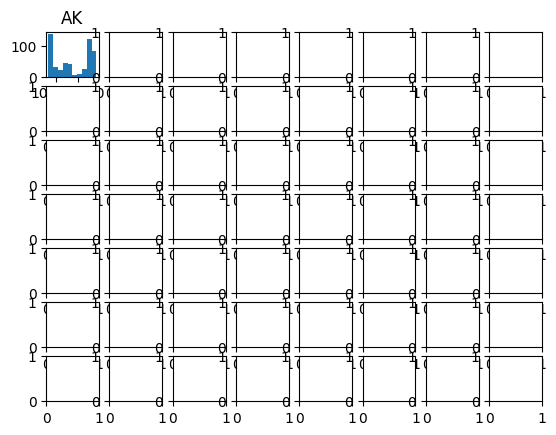

In [ ]:
file_path = '/content/drive/MyDrive/593: Milestone 1 COVID/time_series_covid19_US.csv'

covid_infections_df = pd.read_csv(file_path)

#covid_infections_df.head()

#covid_infections_df.describe()

states = covid_infections_df['state'].unique()
fig, axs = plt.subplots(7,8)
axs = axs.flatten()

for i, state in enumerate(states):
  subset = covid_infections_df[covid_infections_df['state'] == state]

  axs[i].hist(subset['cases_confirmed'])
  axs[i].set_title(state)
plt.show()

In [ ]:
covid_infections_df.isna().groupby(covid_infections_df['state']).sum()
#Different states used different measures for tracking cases

,date,state,cases_conf_probable,cases_confirmed,cases_probable,tests_viral_positive,tests_viral_negative,tests_viral_total,tests_antigen_positive,tests_antigen_total,people_viral_positive,people_viral_total,people_antigen_positive,people_antigen_total,encounters_viral_total,tests_combined_total
state,,,,,,,,,,,,,,,,
AK,0,0,11,399,399,188,188,188,929,929,118,929,929,929,929,188
AL,0,0,928,928,928,0,0,0,928,928,0,0,928,928,928,928
AR,0,0,0,399,399,929,162,0,880,880,0,929,196,196,929,0
AS,0,0,151,525,525,919,919,655,919,919,581,919,919,919,919,655
AZ,0,0,0,401,401,930,931,0,931,931,99,343,931,931,931,0
CA,0,0,0,401,401,931,931,4,931,931,56,931,931,931,931,4
CO,0,0,0,401,401,931,931,931,931,931,50,13,931,931,7,7
CT,0,0,7,405,405,0,0,0,251,251,93,935,935,935,935,0
DC,0,0,0,400,400,930,930,930,930,930,149,282,930,930,204,204
